# Product Analytics – User Retention & Experimentation

## Predictive Modeling Extension

This section extends the product analytics project with predictive modeling. The goal is to predict whether a user will be retained on Day 7 using early engagement features.

## Business Question
Can early user behaviors such as completing onboarding, activation, purchase, and experiment assignment help predict short-term retention?

## Hypotheses

### Product Experiment Hypothesis
- **H0:** The treatment variant does not improve activation or retention.
- **H1:** The treatment variant improves activation or retention.

### Predictive Modeling Hypothesis
- Users with stronger early engagement signals are more likely to be retained on Day 7.

## Models Used
1. **Logistic Regression** as a baseline interpretable classifier
2. **Random Forest** as a more flexible nonlinear model

## Evaluation Metrics
- Accuracy
- Confusion Matrix
- Precision / Recall / F1-score
- ROC Curve
- AUC

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [8]:
df = pd.read_csv("sales.csv", dtype={"order_id": str})

df.head()

,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


In [20]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())
df.head()

['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered', 'price', 'discount_amount', 'category', 'payment_method', 'bi_st', 'cust_id', 'year', 'month', 'ref_num', 'name_prefix', 'first_name', 'middle_initial', 'last_name', 'gender', 'age', 'full_name', 'e_mail', 'customer_since', 'ssn', 'phone_no.', 'place_name', 'county', 'city', 'state', 'zip', 'region', 'user_name', 'order_month']


,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,ssn,phone_no.,place_name,county,city,state,zip,region,user_name,order_month
0,100354678,2020-10-01,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,2020-10
1,100354678,2020-10-01,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,2020-10
2,100354680,2020-10-01,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,2020-10
3,100354680,2020-10-01,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,2020-10
4,100367357,2020-11-13,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,2020-11


In [22]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [24]:
df["order_month"] = df["order_date"].dt.to_period("M")

df["cohort_month"] = (
    df.groupby("cust_id")["order_date"]
    .transform("min")
    .dt.to_period("M")
)

df[["cust_id", "order_date", "order_month", "cohort_month"]].head()

,cust_id,order_date,order_month,cohort_month
0,60124,2020-10-01,2020-10,2020-10
1,60124,2020-10-01,2020-10,2020-10
2,60124,2020-10-01,2020-10,2020-10
3,60124,2020-10-01,2020-10,2020-10
4,60124,2020-11-13,2020-11,2020-10


In [26]:
df["cohort_index"] = (df["order_month"] - df["cohort_month"]).apply(lambda x: x.n)

df[["cust_id", "order_month", "cohort_month", "cohort_index"]].head()

,cust_id,order_month,cohort_month,cohort_index
0,60124,2020-10,2020-10,0
1,60124,2020-10,2020-10,0
2,60124,2020-10,2020-10,0
3,60124,2020-10,2020-10,0
4,60124,2020-11,2020-10,1


In [28]:
cohort_data = (
    df.groupby(["cohort_month", "cohort_index"])["cust_id"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="cust_id"
)

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2020-10,1.0,0.255924,0.239494,0.101738,0.079937,0.105529,0.095419,0.062243,0.091627,0.051501,0.038863,0.05466
2020-11,1.0,0.217793,0.067606,0.041841,0.079938,0.067386,0.038978,0.073993,0.033253,0.023783,0.032592,NaN
2020-12,1.0,0.086329,0.034340,0.045636,0.050577,0.025717,0.045636,0.020322,0.014371,0.020725,NaN,NaN
2021-01,1.0,0.074500,0.053823,0.047260,0.029865,0.036429,0.026584,0.022645,0.023958,NaN,NaN,NaN
2021-02,1.0,0.103722,0.064020,0.037717,0.042680,0.024318,0.017866,0.020844,NaN,NaN,NaN,NaN
2021-03,1.0,0.146051,0.036595,0.062262,0.020533,0.012916,0.020368,NaN,NaN,NaN,NaN,NaN
2021-04,1.0,0.056470,0.036723,0.013944,0.009787,0.011433,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,1.0,0.072436,0.037877,0.023777,0.019077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,1.0,0.075006,0.037849,0.038772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


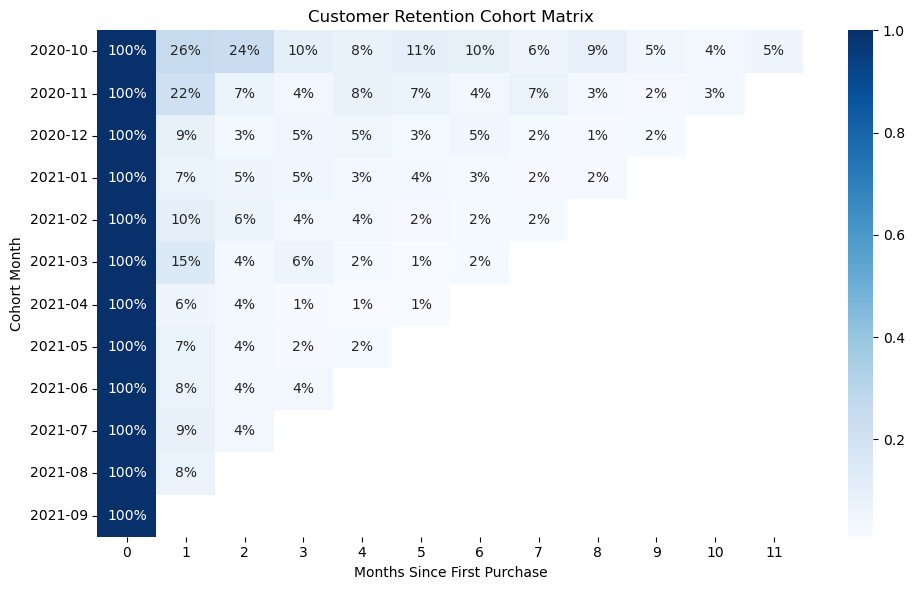

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort Matrix")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

## Cohort Analysis Insights

The cohort retention analysis shows a sharp drop in user retention after the first purchase. Most cohorts experience a significant decline from Month 0 to Month 1, indicating that many users do not return after their initial transaction.

Earlier cohorts, such as October 2020, show relatively stronger retention compared to later cohorts like January and February 2021. This suggests that user retention performance may be deteriorating over time.

Long-term retention beyond 6 months is consistently low across all cohorts, generally falling below 10%. This indicates that the business struggles to maintain sustained customer engagement.

Overall, the results highlight a critical need to improve early-stage user retention, particularly in the first one to two months after acquisition.

## Business Implications

The sharp drop in retention after the first purchase suggests that the onboarding and early user experience may not be sufficiently engaging to encourage repeat behavior.

Product teams should focus on improving the first 30-day experience, including personalized recommendations, promotions, or follow-up engagement strategies to increase repeat purchases.

Additionally, the decline in retention across newer cohorts suggests that recent changes in acquisition channels, pricing, or product experience may be negatively impacting user quality.

## FUNNEL ANALYSIS

In [43]:
customer_df = df.groupby("cust_id").agg(
    num_orders=("order_id", "count"),
    total_spent=("price", "sum"),
    total_discount=("discount_amount", "sum"),
    total_qty=("qty_ordered", "sum")
).reset_index()

# Net revenue (more realistic)
customer_df["net_spent"] = customer_df["total_spent"] - customer_df["total_discount"]

customer_df.head()

,cust_id,num_orders,total_spent,total_discount,total_qty,net_spent
0,4,41,47400.3,3406.010,82,43994.290
1,15,6,198.3,0.000,13,198.300
2,16,20,16106.9,1121.001,38,14985.899
3,20,11,31594.7,2875.682,22,28719.018
4,21,1,21.0,0.000,6,21.000


In [45]:
customer_df["repeat"] = (customer_df["num_orders"] > 1).astype(int)

median_spend = customer_df["net_spent"].median()
customer_df["high_value"] = (customer_df["net_spent"] > median_spend).astype(int)

In [47]:
funnel = pd.DataFrame({
    "step": ["first_purchase", "repeat_purchase", "high_value"],
    "users": [
        customer_df["cust_id"].nunique(),
        customer_df.loc[customer_df["repeat"] == 1, "cust_id"].nunique(),
        customer_df.loc[customer_df["high_value"] == 1, "cust_id"].nunique()
    ]
})

funnel

,step,users
0,first_purchase,64248
1,repeat_purchase,37801
2,high_value,32123


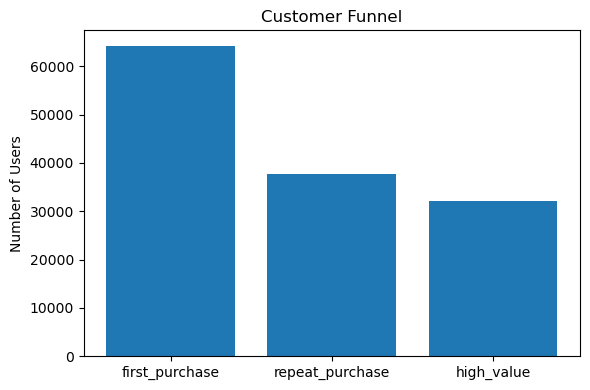

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(funnel["step"], funnel["users"])
plt.title("Customer Funnel")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

In [51]:
funnel["conversion_rate"] = funnel["users"] / funnel["users"].iloc[0]
funnel

,step,users,conversion_rate
0,first_purchase,64248,1.000000
1,repeat_purchase,37801,0.588361
2,high_value,32123,0.499984


## Funnel Insights

The largest drop occurs between first purchase and repeat purchase, indicating weak early retention. This aligns with the cohort analysis, which showed a sharp decline after the first month.

Improving repeat purchase behavior should be a key priority, as it directly impacts long-term customer value.

## A/B TEST SIMULATION

In [57]:
import numpy as np

np.random.seed(42)

customer_df["variant"] = np.random.choice(["control", "treatment"], size=len(customer_df))

In [59]:
ab_table = pd.crosstab(customer_df["variant"], customer_df["repeat"])
ab_table

repeat,0,1
variant,,
control,13277,18840
treatment,13170,18961


In [61]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ab_table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 0.8027413620085994
P-value: 0.37027500917862355


## A/B Test Results

The chi-square test was conducted to evaluate whether the treatment group had a higher repeat purchase rate than the control group.

The resulting p-value is 0.37, which is significantly greater than the 0.05 threshold. Therefore, we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference in repeat purchase behavior between the control and treatment groups.

## Interpretation

The simulated treatment does not appear to improve user retention. This suggests that the change being tested may not have a meaningful impact on customer behavior.

Further experimentation or alternative product interventions may be required to drive improvements in retention.

## MACHINE LEARNING MODEL

In [84]:
customer_df["avg_order_value"] = customer_df["net_spent"] / customer_df["num_orders"]

features = ["net_spent", "total_qty", "avg_order_value", "variant"]

X = customer_df[features]
y = customer_df["repeat"]

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [88]:
## MODEL 1: LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [90]:
## MODEL 2: RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [92]:
from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Accuracy: 0.9635019455252918
Random Forest Accuracy: 0.9709727626459144


In [94]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic:\n", cm_log)
print("\nRandom Forest:\n", cm_rf)

Logistic:
 [[5046  244]
 [ 225 7335]]

Random Forest:
 [[5040  250]
 [ 123 7437]]


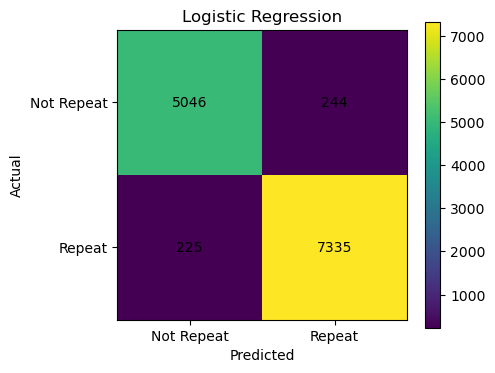

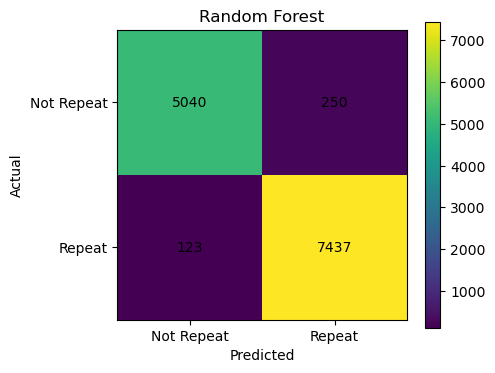

In [96]:
def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    labels = ["Not Repeat", "Repeat"]
    plt.xticks([0,1], labels)
    plt.yticks([0,1], labels)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_cm(cm_log, "Logistic Regression")
plot_cm(cm_rf, "Random Forest")

In [98]:
from sklearn.metrics import classification_report

print("Logistic:\n", classification_report(y_test, y_pred_log))
print("\nRandom Forest:\n", classification_report(y_test, y_pred_rf))

Logistic:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96      5290
           1       0.97      0.97      0.97      7560

    accuracy                           0.96     12850
   macro avg       0.96      0.96      0.96     12850
weighted avg       0.96      0.96      0.96     12850


Random Forest:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96      5290
           1       0.97      0.98      0.98      7560

    accuracy                           0.97     12850
   macro avg       0.97      0.97      0.97     12850
weighted avg       0.97      0.97      0.97     12850



In [100]:
from sklearn.metrics import roc_curve, roc_auc_score

log_auc = roc_auc_score(y_test, y_prob_log)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Logistic AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

Logistic AUC: 0.9950380822356248
Random Forest AUC: 0.9985348966303597


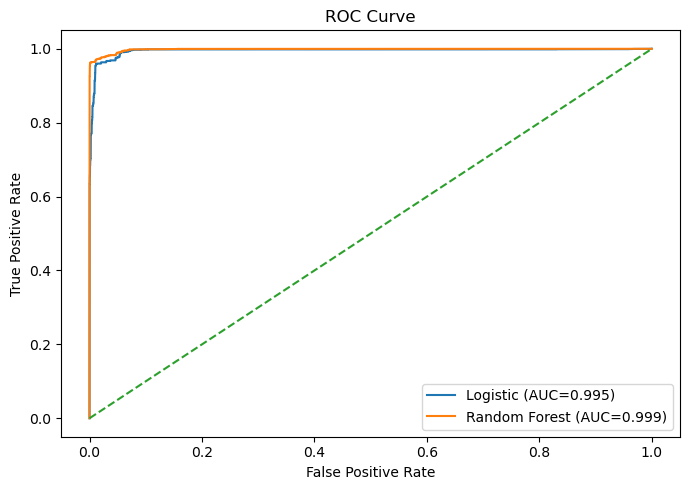

In [102]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={log_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [104]:
importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance

,feature,importance
1,total_qty,0.747007
0,net_spent,0.172468
2,avg_order_value,0.080498
3,variant,0.000027


## Model Comparison Insights

Both models perform well in predicting repeat purchase behavior. However, the Random Forest model shows a clear improvement in identifying repeat customers.

Specifically, Random Forest significantly reduces false negatives, meaning it is better at detecting users who are likely to return.

From a business perspective, this is critical because missing a repeat customer (false negative) means losing an opportunity to reinforce engagement or increase lifetime value.

Therefore, Random Forest is the preferred model when the goal is to identify and retain high-value returning customers.

## Feature Importance Insights

The Random Forest model shows that total quantity purchased is by far the most important predictor of repeat behavior, accounting for nearly 75% of the model’s decision-making.

This indicates that deeper engagement, measured by the number of items purchased, is a stronger signal of retention than monetary value alone.

While total spending also contributes to predicting repeat behavior, its impact is significantly smaller. Additionally, average order value has limited importance, suggesting that high-value purchases do not necessarily translate into long-term customer retention.

Finally, the experimental variant has negligible importance, reinforcing earlier findings that the tested treatment does not significantly influence user behavior.

## ROC Curve Interpretation

Both Logistic Regression and Random Forest models achieve near-perfect AUC scores (0.995 and 0.999 respectively), indicating excellent ability to distinguish between repeat and non-repeat customers.

The ROC curves show that both models maintain a high true positive rate while keeping the false positive rate very low across thresholds. This suggests strong separability in the dataset.

However, the high performance is likely driven by the use of aggregated behavioral features such as total quantity purchased and total spending, which are closely correlated with repeat behavior.

Therefore, while the models perform extremely well, their predictive power may be optimistic compared to real-world scenarios where only early-stage user signals are available.